# G4 Intersect Analysis — Chosen Parameters

Compares motif-type subsets derived from the union of G4Discovery and rG4detector results,
after applying a chosen G4D quality threshold.
For the parameter sweep that justifies the threshold choice, see **g4_param_exploration.ipynb**.

Subsets analysed:
| Subset | Description |
|--------|-------------|
| Union | All motifs after threshold filter (G4D-only + rG4D-only + both) |
| Intersection | Motifs detected by both tools |
| All G4D motifs | Motifs predicted by G4Discovery (G4D-only + both) |
| G4D-only motifs | G4D predictions with no rG4D overlap |
| All rG4D motifs | Motifs detected by rG4detector (rG4D-only + both) |
| rG4D-only motifs | rG4D peaks with no G4Discovery overlap |

## 1. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload
import sys; sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/secondrna/workflow/")
from utils import g4_analysis_lib as lib
from IPython.display import display, Markdown
from matplotlib_venn import venn2

reload(lib)

SAMPLE = "gencode.v47"
os.chdir("/mnt/cbib/LNClassifier/paper/secondrna")
print("Imports OK")

Imports OK


## 2. Data Loading

In [ ]:
G4DISCOVERY_PATH = f"results/{SAMPLE}/g4discovery/{SAMPLE}.g4Discovery.transcripts.bed.gz"
INTERSECT_PATH   = f"results/{SAMPLE}/{SAMPLE}.g4Discovery.rG4detector.intersect.bed"
PEAKS_PATH       = f"results/{SAMPLE}/rg4detector/{SAMPLE}.rG4detector.peaks.bed"
CODING_ANN_PATH  = f"results/{SAMPLE}/{SAMPLE}.coding_annotation.tsv"
LENGTH_ANN_PATH  = f"results/{SAMPLE}/{SAMPLE}.transcript_lengths.tsv"

intersect  = lib.load_intersect(INTERSECT_PATH)
peaks      = lib.load_peaks(PEAKS_PATH)
coding_ann = lib.load_coding_annotation(CODING_ANN_PATH)
length_ann = lib.load_length_annotation(LENGTH_ANN_PATH)

union_df = lib.build_union_df(intersect, peaks)
union_df = lib.annotate_union(union_df, coding_ann, length_ann)

assert "real"      in union_df.columns
assert "tx_len_nt" in union_df.columns
assert set(union_df["type"].unique()) <= {"both", "G4D only", "RG4D only"}
print(f"union_df: {union_df.shape}  types: {union_df['type'].value_counts().to_dict()}")

/mnt/cbib/LNClassifier/paper/secondrna/workflow/utils/g4_analysis_lib.py:122: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  union["overlaps"] = union["overlaps"].fillna(False).astype(bool)


union_df: (61850, 19)  types: {'RG4D only': 30570, 'G4D only': 16773, 'both': 14507}


## 3. Parameter Choice

Set the G4Discovery quality thresholds here.
See **g4_param_exploration.ipynb** for the sweep that informed this choice.

In [ ]:
# ── Chosen G4D quality thresholds ─────────────────────────────────────────────
PQS_TH = 40   # pqsfinder score minimum
G4H_TH = 1.2  # G4Hunter score minimum

filtered_union = lib.apply_g4d_threshold(union_df, PQS_TH, G4H_TH)
subsets = lib.build_type_subsets(filtered_union)

print(f"Threshold: pqs≥{PQS_TH}, G4H≥{G4H_TH}")
for spec, sdf in subsets:
    print(f"  {spec.label:30s}  {len(sdf):,} motifs")

Threshold: pqs≥40, G4H≥1.2
  Union (all motifs)              57,372 motifs
  Intersection (both tools)       14,202 motifs
  All G4D motifs                  26,802 motifs
  G4D-only motifs                 12,600 motifs
  All rG4D motifs                 44,772 motifs
  rG4D-only motifs                30,570 motifs


## 4. Analysis helpers

In [ ]:
_TYPE_PALETTE = {"G4D only": "#B388EB", "both": "#8093F1", "RG4D only": "#72DDF7"}
_OVERLAP_PALETTE = {
    "No rG4D overlap":   _TYPE_PALETTE["G4D only"],
    "With rG4D overlap": _TYPE_PALETTE["both"],
}
_CLASS_ORDER  = ["Protein-coding", "Non-coding", "Unannotated"]

# Use Arial globally for matplotlib/seaborn plots
plt.rcParams["font.family"] = "Arial"
sns.set_theme(style="white", font="Arial")

def run_subset_analysis(spec, sdf, coding_ann, length_ann):
    """Full analysis for one subset; returns numeric results dict."""
    display(Markdown(f"---\n## Subset: {spec.label}\n`{len(sdf):,}` motifs"))

    # ── Aggregate Statistics ──────────────────────────────────────────────
    display(Markdown("### Aggregate Statistics"))
    agg = lib.compute_aggregate_stats(sdf)
    display(pd.DataFrame([agg]).T.rename(columns={0: "value"}))

    if agg["g4d_total"] > 0 and agg["rg4d_total"] > 0:
        fig, ax = plt.subplots(figsize=(5, 5))
        v = venn2(
            subsets=(agg["g4d_only"], agg["rg4d_only"], agg["both"]),
            set_labels=("g4Discovery", "rG4detector"),
            ax=ax,
        )
        for pid, key in [("10", "G4D only"), ("01", "RG4D only"), ("11", "both")]:
            patch = v.get_patch_by_id(pid)
            if patch:
                patch.set_color(_TYPE_PALETTE[key])
                patch.set_alpha(0.7)
        ax.set_title(f"Tool overlap — {spec.label}")
        plt.tight_layout(); plt.show()

    # ── Coding Breakdown ──────────────────────────────────────────────────
    display(Markdown("### Coding Breakdown"))
    class_bk = lib.compute_coding_breakdown(sdf)
    if not class_bk.empty:
        display(
            class_bk.style.format({
                "Total motifs": "{:,}", "With rG4D overlap": "{:,}", "Overlap (%)": "{:.1f}"
            })
        )
        type_df = sdf.copy()
        type_df["coding_class"] = (
            type_df["real"].map({True: "Protein-coding", False: "Non-coding"}).fillna("Unannotated")
        )
        type_counts = (
            type_df.groupby(["coding_class", "type"]).size()
            .unstack(fill_value=0)
            .reindex([c for c in _CLASS_ORDER if c in type_df["coding_class"].unique()])
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(type_counts))
        bottoms = np.zeros(len(type_counts))
        for mtype in ["G4D only", "both", "RG4D only"]:
            if mtype in type_counts.columns:
                vals = type_counts[mtype].values
                ax.bar(x, vals, bottom=bottoms, color=_TYPE_PALETTE[mtype], label=mtype)
                bottoms += vals
        ax.set_xticks(x); ax.set_xticklabels(type_counts.index)
        ax.set_ylabel("Motifs")
        ax.set_title(f"Coding breakdown — {spec.label}")
        ax.legend(title="Motif type"); plt.tight_layout(); plt.show()

    # ── Length & Position ─────────────────────────────────────────────────
    display(Markdown("### Length & Position"))
    pos_start = "rg4d_start" if spec.name in ("rg4d_only", "all_rg4d") else "start"
    pos_end   = "rg4d_end"   if spec.name in ("rg4d_only", "all_rg4d") else "end"
    pos_sdf = sdf.dropna(subset=["tx_len_nt", "real"]).copy()
    pos_sdf = pos_sdf[pos_sdf[pos_start] >= 0]
    if not pos_sdf.empty:
        pos_sdf["relative_pos"] = (
            (pos_sdf[pos_start] + pos_sdf[pos_end]) / 2 / pos_sdf["tx_len_nt"]
        )
        pos_sdf = pos_sdf[pos_sdf["relative_pos"].between(0, 1)]
        pos_sdf["class"] = pos_sdf["real"].map({True: "Protein-coding", False: "Non-coding"})
        fig, ax = plt.subplots(figsize=(7, 4))
        for label, color in [("Protein-coding", "#d95f02"), ("Non-coding", "#9467bd")]:
            vals = pos_sdf.loc[pos_sdf["class"] == label, "relative_pos"]
            if vals.nunique() > 1:
                sns.kdeplot(vals, ax=ax, label=label, color=color, fill=True, alpha=0.3)
        ax.set_xlabel("Relative position (0 = 5′, 1 = 3′)")
        ax.set_ylabel("Density")
        ax.set_title(f"Positional distribution — {spec.label}")
        ax.legend(); ax.set_xlim(0, 1); plt.tight_layout(); plt.show()
    else:
        print("  (position data unavailable for this subset)")

    # ── Score Analysis ────────────────────────────────────────────────────
    display(Markdown("### Score Analysis"))
    score_col = "rg4d_score" if spec.name in ("rg4d_only", "all_rg4d") else "g4HunterScore"
    score_sdf = sdf[sdf[score_col] > 0].copy()
    # Only show comparison violin when both overlap classes are present
    if not score_sdf.empty and score_sdf["overlaps"].nunique() == 2:
        score_sdf["Overlap"] = score_sdf["overlaps"].map(
            {True: "With rG4D overlap", False: "No rG4D overlap"}
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.violinplot(
            data=score_sdf, x="Overlap", y=score_col,
            hue="Overlap", palette=_OVERLAP_PALETTE, ax=ax, inner="box", legend=False,
            order=["No rG4D overlap", "With rG4D overlap"],
        )
        ax.set_ylabel(score_col)
        ax.set_title(f"Score distribution — {spec.label}")
        plt.tight_layout(); plt.show()
    else:
        print(f"  (score comparison not applicable for {spec.label})")

    # ── Statistical Tests ─────────────────────────────────────────────────
    # Stats run on all motifs in the subset: counts motif presence per transcript,
    # so each subset tests the question appropriate to its membership.
    display(Markdown("### Statistical Tests"))
    test_res = lib.run_statistical_tests(sdf, coding_ann, length_ann)
    display(pd.DataFrame([test_res]).T.rename(columns={0: "value"}))

    return {"spec": spec, "agg_stats": agg, "class_breakdown": class_bk, "test_results": test_res}


## 5. Results

---
## Subset: Union (all motifs)
`57,372` motifs

### Aggregate Statistics

,value
total,57372.000000
both,14202.000000
g4d_only,12600.000000
rg4d_only,30570.000000
g4d_total,26802.000000
rg4d_total,44772.000000
g4d_overlap_frac,0.529886
rg4d_overlap_frac,0.317207
n_g4d_in_pc,9971.000000
n_g4d_in_lncrna,2887.000000


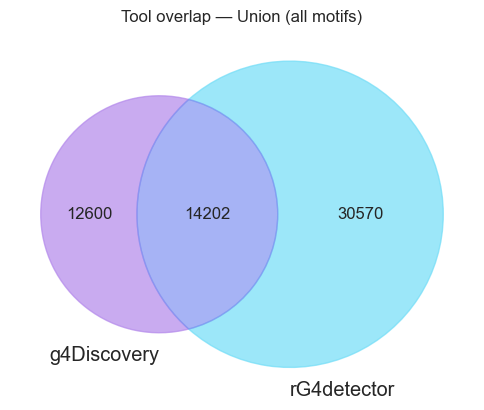

### Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
nan,"33,418","7,567",22.6
Non-coding,"6,132","1,533",25.0
Protein-coding,"17,822","5,102",28.6


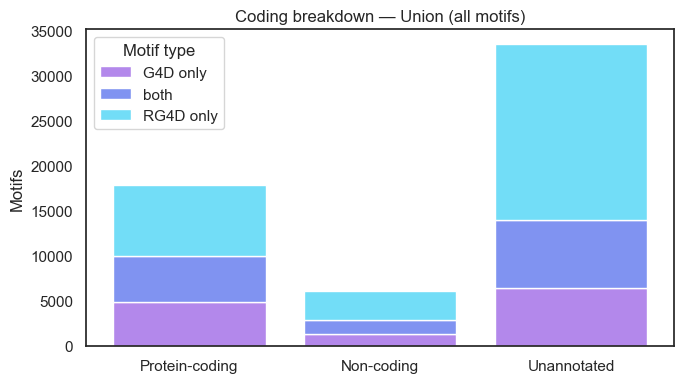

### Length & Position

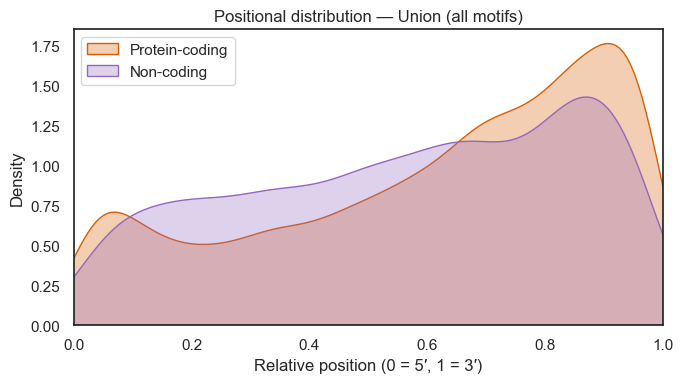

### Score Analysis

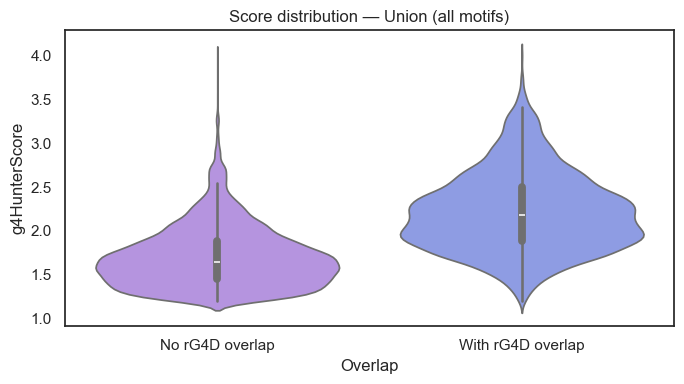

### Statistical Tests

,value
chi2,1.158981e+03
p_chi2,5.013073e-254
cramers_v,1.018837e-01
u_stat,1.603575e+09
p_mwu,5.339230e-215
vda,5.335930e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: Intersection (both tools)
`14,202` motifs

### Aggregate Statistics

,value
total,14202.000000
both,14202.000000
g4d_only,0.000000
rg4d_only,0.000000
g4d_total,14202.000000
rg4d_total,14202.000000
g4d_overlap_frac,1.000000
rg4d_overlap_frac,1.000000
n_g4d_in_pc,5102.000000
n_g4d_in_lncrna,1533.000000


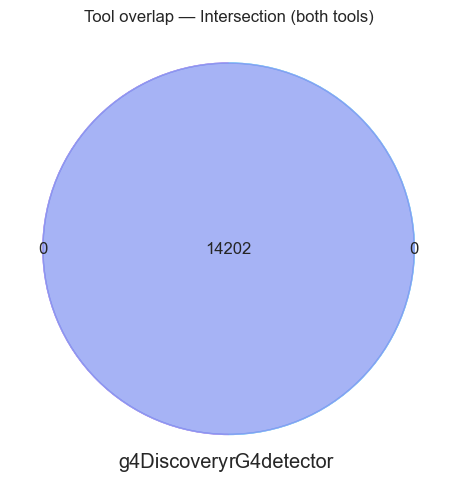

### Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
nan,"7,567","7,567",100.0
Non-coding,"1,533","1,533",100.0
Protein-coding,"5,102","5,102",100.0


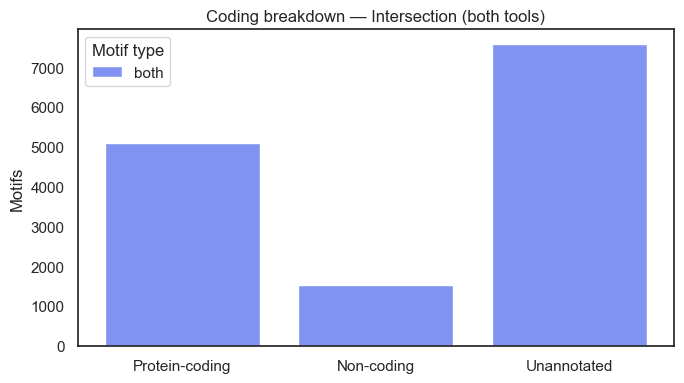

### Length & Position

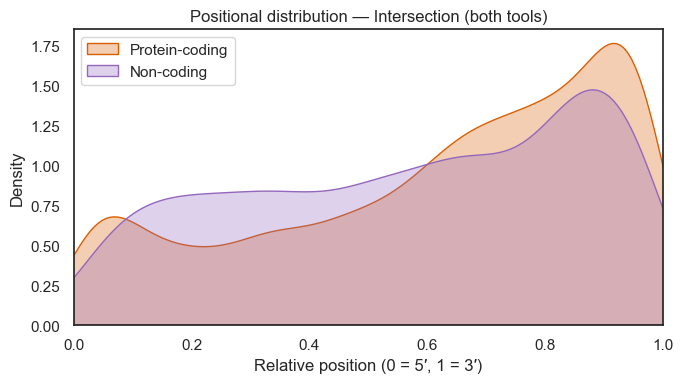

### Score Analysis

  (score comparison not applicable for Intersection (both tools))


### Statistical Tests

,value
chi2,5.914088e+02
p_chi2,1.237300e-130
cramers_v,7.277976e-02
u_stat,1.549345e+09
p_mwu,4.128015e-125
vda,5.155480e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: All G4D motifs
`26,802` motifs

### Aggregate Statistics

,value
total,26802.000000
both,14202.000000
g4d_only,12600.000000
rg4d_only,0.000000
g4d_total,26802.000000
rg4d_total,14202.000000
g4d_overlap_frac,0.529886
rg4d_overlap_frac,1.000000
n_g4d_in_pc,9971.000000
n_g4d_in_lncrna,2887.000000


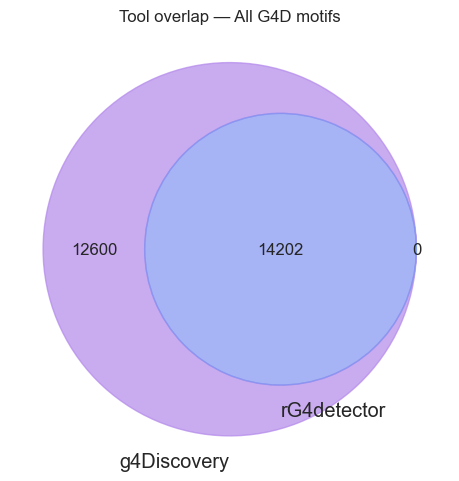

### Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
nan,"13,944","7,567",54.3
Non-coding,"2,887","1,533",53.1
Protein-coding,"9,971","5,102",51.2


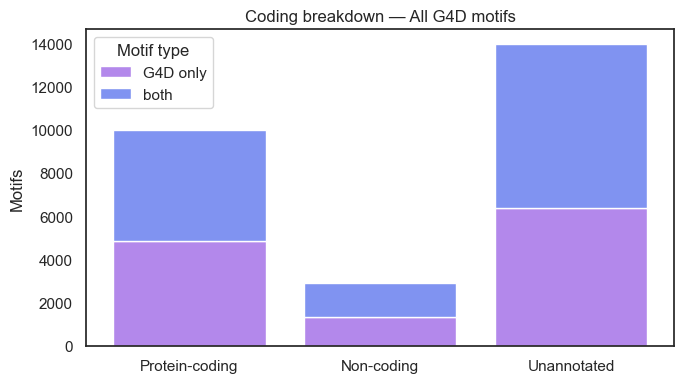

### Length & Position

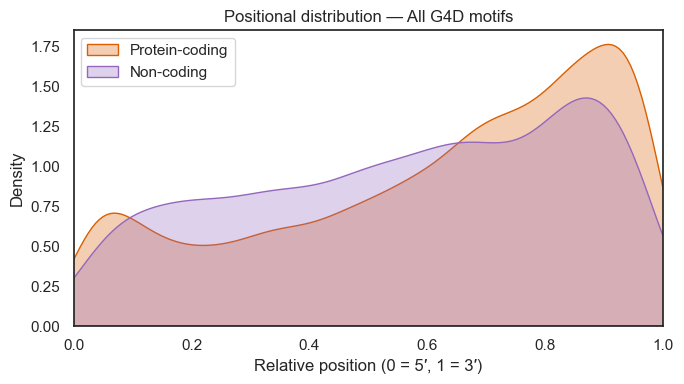

### Score Analysis

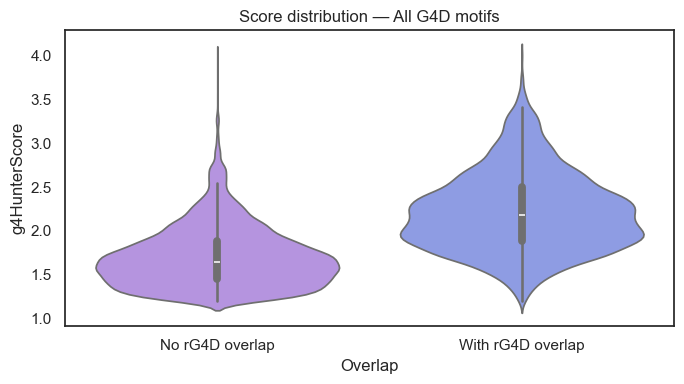

### Statistical Tests

,value
chi2,1.052139e+03
p_chi2,8.344347e-231
cramers_v,9.707409e-02
u_stat,1.581055e+09
p_mwu,8.236670e-216
vda,5.260994e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D-only motifs
`12,600` motifs

### Aggregate Statistics

,value
total,12600.000000
both,0.000000
g4d_only,12600.000000
rg4d_only,0.000000
g4d_total,12600.000000
rg4d_total,0.000000
g4d_overlap_frac,0.000000
rg4d_overlap_frac,0.000000
n_g4d_in_pc,4869.000000
n_g4d_in_lncrna,1354.000000


### Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
nan,"6,377",0,0.0
Non-coding,"1,354",0,0.0
Protein-coding,"4,869",0,0.0


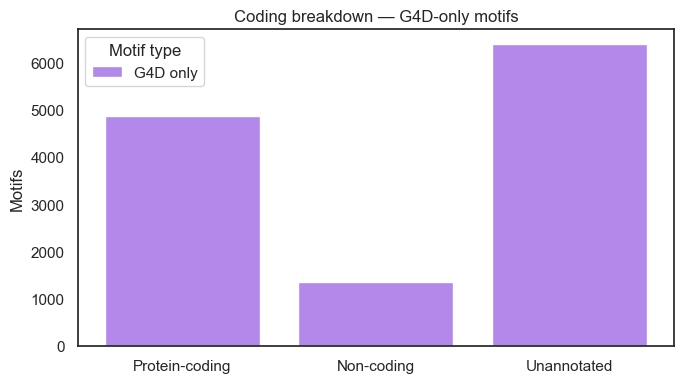

### Length & Position

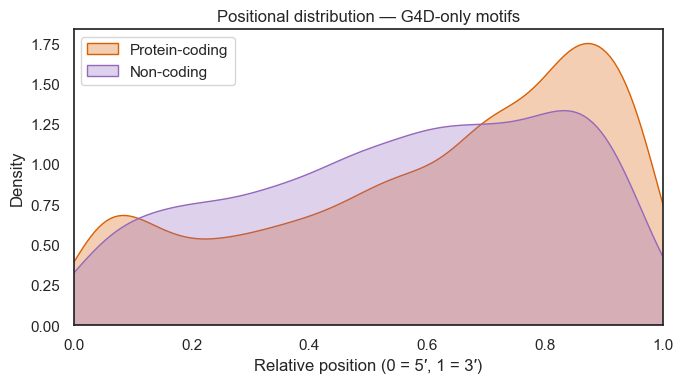

### Score Analysis

  (score comparison not applicable for G4D-only motifs)


### Statistical Tests

,value
chi2,6.728034e+02
p_chi2,2.454424e-148
cramers_v,7.762665e-02
u_stat,1.550575e+09
p_mwu,9.833663e-144
vda,5.159572e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: All rG4D motifs
`44,772` motifs

### Aggregate Statistics

,value
total,44772.000000
both,14202.000000
g4d_only,0.000000
rg4d_only,30570.000000
g4d_total,14202.000000
rg4d_total,44772.000000
g4d_overlap_frac,1.000000
rg4d_overlap_frac,0.317207
n_g4d_in_pc,5102.000000
n_g4d_in_lncrna,1533.000000


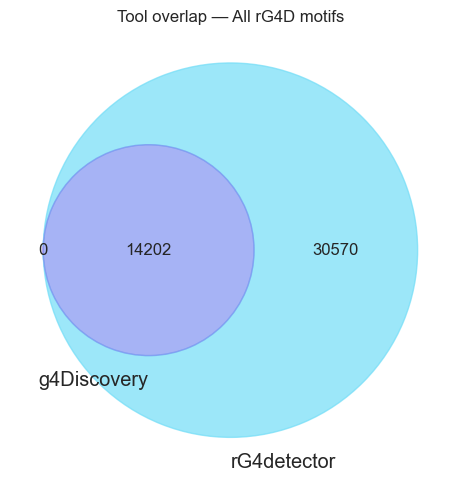

### Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
nan,"27,041","7,567",28.0
Non-coding,"4,778","1,533",32.1
Protein-coding,"12,953","5,102",39.4


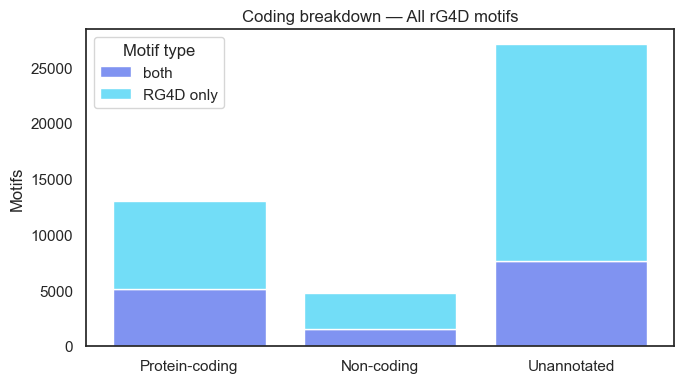

### Length & Position

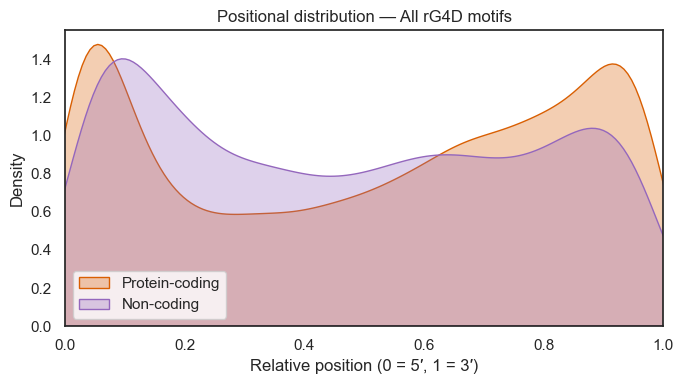

### Score Analysis

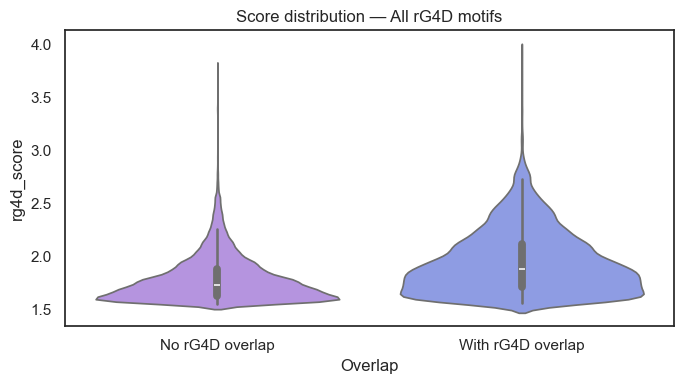

### Statistical Tests

,value
chi2,8.090527e+02
p_chi2,5.805667e-178
cramers_v,8.512461e-02
u_stat,1.580476e+09
p_mwu,2.386110e-152
vda,5.259067e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: rG4D-only motifs
`30,570` motifs

### Aggregate Statistics

,value
total,30570.0
both,0.0
g4d_only,0.0
rg4d_only,30570.0
g4d_total,0.0
rg4d_total,30570.0
g4d_overlap_frac,0.0
rg4d_overlap_frac,0.0
n_g4d_in_pc,0.0
n_g4d_in_lncrna,0.0


### Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
nan,"19,474",0,0.0
Non-coding,"3,245",0,0.0
Protein-coding,"7,851",0,0.0


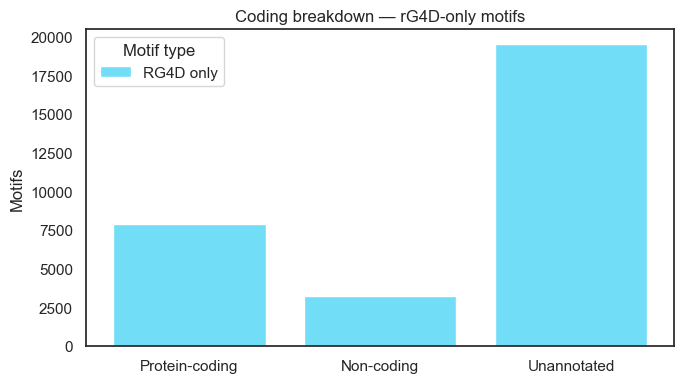

### Length & Position

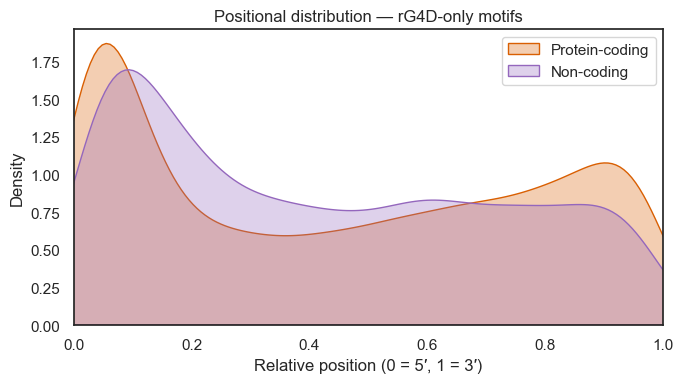

### Score Analysis

  (score comparison not applicable for rG4D-only motifs)


### Statistical Tests

,value
chi2,4.563876e+02
p_chi2,2.937778e-101
cramers_v,6.393426e-02
u_stat,1.553258e+09
p_mwu,3.707343e-89
vda,5.168501e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04



Done. 6 subsets processed.


In [ ]:
all_results = {}
for spec, sdf in subsets:
    result = run_subset_analysis(spec, sdf, coding_ann, length_ann)
    all_results[spec.name] = result
print(f"\nDone. {len(all_results)} subsets processed.")

## 6. Cross-Subset Comparison

In [ ]:
comp_df = lib.compare_results(all_results)
display(
    comp_df[[
        "total_motifs", "g4d_total", "rg4d_total", "both", "g4d_overlap_frac",
        "cramers_v", "p_chi2", "vda", "p_mwu",
        "median_coding_per_kb", "median_lncrna_per_kb",
    ]]
    .style
    .format({
        "total_motifs": "{:,}", "g4d_total": "{:,}", "rg4d_total": "{:,}", "both": "{:,}",
        "g4d_overlap_frac": "{:.3f}",
        "cramers_v": "{:.4f}", "p_chi2": "{:.2e}",
        "vda": "{:.4f}", "p_mwu": "{:.2e}",
        "median_coding_per_kb": "{:.4f}", "median_lncrna_per_kb": "{:.4f}",
    })
    .background_gradient(subset=["cramers_v", "vda"], cmap="YlOrRd")
)

,total_motifs,g4d_total,rg4d_total,both,g4d_overlap_frac,cramers_v,p_chi2,vda,p_mwu,median_coding_per_kb,median_lncrna_per_kb
subset,,,,,,,,,,,
Union (all motifs),"57,372","26,802","44,772","14,202",0.530,0.1019,5.01e-254,0.5336,5.34e-215,0.0000,0.0000
Intersection (both tools),"14,202","14,202","14,202","14,202",1.000,0.0728,1.24e-130,0.5155,4.13e-125,0.0000,0.0000
All G4D motifs,"26,802","26,802","14,202","14,202",0.530,0.0971,8.34e-231,0.5261,8.24e-216,0.0000,0.0000
G4D-only motifs,"12,600","12,600",0,0,0.000,0.0776,2.45e-148,0.5160,9.83e-144,0.0000,0.0000
All rG4D motifs,"44,772","14,202","44,772","14,202",1.000,0.0851,5.81e-178,0.5259,2.39e-152,0.0000,0.0000
rG4D-only motifs,"30,570",0,"30,570",0,0.000,0.0639,2.94e-101,0.5169,3.71e-89,0.0000,0.0000


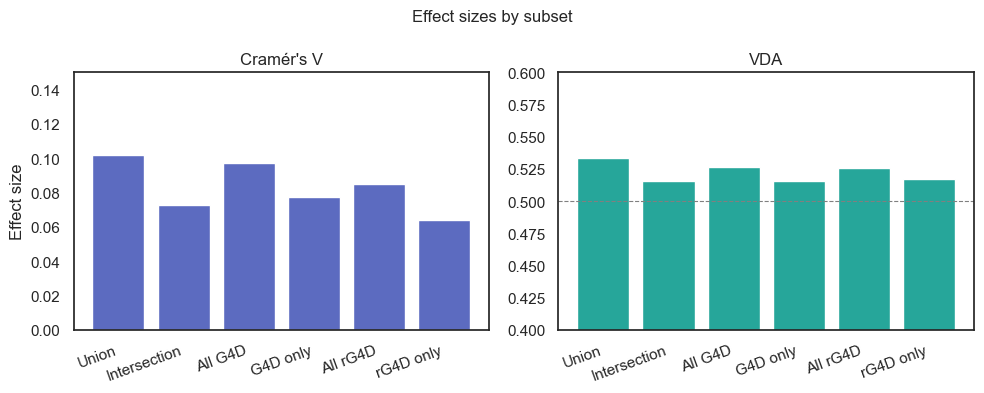

In [ ]:
_SHORT_LABELS = {
    "Union (all motifs)":        "Union",
    "Intersection (both tools)": "Intersection",
    "All G4D motifs":            "All G4D",
    "G4D-only motifs":           "G4D only",
    "All rG4D motifs":           "All rG4D",
    "rG4D-only motifs":          "rG4D only",
}

xlabels = [_SHORT_LABELS.get(l, l) for l in comp_df.index]
x = np.arange(len(comp_df))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(x, comp_df["cramers_v"], color="#5C6BC0")
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(xlabels, rotation=20, ha="right")
ax1.set_ylim(0, 0.15); ax1.set_ylabel("Effect size"); ax1.set_title("Cramér's V")

ax2.bar(x, comp_df["vda"], color="#26A69A")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(xlabels, rotation=20, ha="right")
ax2.set_ylim(0.4, 0.6); ax2.set_title("VDA")

plt.suptitle("Effect sizes by subset", fontsize=12)
plt.tight_layout(); plt.show()
